# Modelamiento — Punto 2: Regresión para Consultoría en Desarrollo Global
**Taller 1 · Consultoría Económica con IA** | David Rodríguez · Juan Rueda · 2026

In [36]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path().resolve()
DIR_DATOS    = NOTEBOOK_DIR / "Datos"

df = pd.read_csv(DIR_DATOS / "life_expectancy_clean.csv")
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape: (2912, 18)
Columnas: ['Year', 'life_expectancy', 'adult_mortality', 'alcohol', 'health_exp_pct_gdp', 'measles', 'bmi', 'gov_health_exp_pct', 'population', 'hdi_income', 'schooling', 'develop_status', 'id', 'log_hiv_aids', 'log_gdp_per_capita', 'thinness_avg', 'vaccination_index', 'postneonatal_deaths']


# 1. Features y Split Temporal

In [37]:
COLS_DROP = [
    "Country", "id",
    "hiv_aids", "gdp_per_capita",
    "thinness_10_19", "thinness_5_9",
    "hepatitis_b", "polio", "diphtheria",
    "infant_deaths", "under5_deaths",
]

TARGET       = "life_expectancy"
FEATURE_COLS = [c for c in df.columns if c not in COLS_DROP + [TARGET]]

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

train_mask   = df["Year"] <= 2012
X_train_raw  = df.loc[train_mask,  FEATURE_COLS]
X_test_raw   = df.loc[~train_mask, FEATURE_COLS]
y_train      = df.loc[train_mask,  TARGET]
y_test       = df.loc[~train_mask, TARGET]

print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")

Features (16): ['Year', 'adult_mortality', 'alcohol', 'health_exp_pct_gdp', 'measles', 'bmi', 'gov_health_exp_pct', 'population', 'hdi_income', 'schooling', 'develop_status', 'log_hiv_aids', 'log_gdp_per_capita', 'thinness_avg', 'vaccination_index', 'postneonatal_deaths']
Train: (2366, 16)  |  Test: (546, 16)


# 2. Estandarización

In [38]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

df_train = pd.DataFrame(X_train, columns=FEATURE_COLS)
df_test  = pd.DataFrame(X_test,  columns=FEATURE_COLS)

print("df_train shape:", df_train.shape)
display(df_train.describe().round(3))

df_train shape: (2366, 16)


,Year,adult_mortality,alcohol,health_exp_pct_gdp,measles,bmi,gov_health_exp_pct,population,hdi_income,schooling,develop_status,log_hiv_aids,log_gdp_per_capita,thinness_avg,vaccination_index,postneonatal_deaths
count,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000,2366.000
mean,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.604,-1.300,-1.184,-0.435,-0.216,-1.849,-2.263,-0.261,-2.377,-3.522,-0.462,-0.551,-3.548,-1.084,-3.556,-0.267
25%,-0.802,-0.727,-0.890,-0.419,-0.216,-0.958,-0.664,-0.256,-0.862,-0.580,-0.462,-0.551,-0.716,-0.750,-0.545,-0.267
50%,0.000,-0.174,-0.210,-0.370,-0.215,0.263,-0.076,-0.226,0.194,0.103,-0.462,-0.551,-0.025,-0.338,0.428,-0.246
75%,0.802,0.483,0.764,-0.145,-0.181,0.916,0.639,-0.098,0.774,0.697,-0.462,0.124,0.649,0.519,0.742,-0.139
max,1.604,4.346,3.270,8.863,17.258,1.973,4.820,20.223,1.776,2.629,2.165,4.198,2.282,5.161,0.883,14.646


# 3. OLS con Elastic Net

In [39]:
enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-3, 1, 50),
    cv=5,
    max_iter=10_000,
    random_state=1999,
)
enet.fit(X_train, y_train)

print(f"Mejor alpha:    {enet.alpha_:.4f}")
print(f"Mejor l1_ratio: {enet.l1_ratio_:.2f}")

for name, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    pred = enet.predict(X)
    print(f"{name} --")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y, pred)):.4f}")
    print(f"  MAE:  {mean_absolute_error(y, pred):.4f}")
    print(f"  R2:   {r2_score(y, pred):.4f}")

coefs = pd.Series(enet.coef_, index=FEATURE_COLS).sort_values(key=abs, ascending=False)
print(f"Variables seleccionadas: {(coefs != 0).sum()} / {len(coefs)}")
print(coefs[coefs != 0].to_string())

Mejor alpha:    0.0625
Mejor l1_ratio: 1.00
Train --
  RMSE: 3.0978
  MAE:  2.2928
  R2:   0.8971
Test --
  RMSE: 2.8728
  MAE:  2.1562
  R2:   0.8801
Variables seleccionadas: 12 / 16
hdi_income             5.603795
log_hiv_aids          -3.030316
adult_mortality       -1.236354
gov_health_exp_pct     0.339337
health_exp_pct_gdp     0.326906
vaccination_index      0.312608
alcohol               -0.285429
postneonatal_deaths   -0.222184
measles               -0.164552
develop_status         0.141506
Year                   0.141434
population             0.071877


# 4. Random Forest

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_distributions = {
    "n_estimators":      [200, 400, 600, 900],
    "max_depth":         [None, 8, 12, 16, 22],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 2, 5, 10],
    "max_features":      ["sqrt", "log2", 0.4, 0.7],
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=1999, n_jobs=-1),
    param_distributions=rf_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=1999,
    n_jobs=-1,
    refit=True,
)
random_rf.fit(X_train, y_train)
rf_model = random_rf.best_estimator_

print("Mejores hiperparámetros RF:")
print(random_rf.best_params_)

for name, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    pred = rf_model.predict(X)
    print(f"{name} -- RMSE: {np.sqrt(mean_squared_error(y, pred)):.4f}  R²: {r2_score(y, pred):.4f}")

Mejores hiperparámetros RF:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.4, 'max_depth': 22}
Train -- RMSE: 1.3347  R²: 0.9809
Test -- RMSE: 2.1151  R²: 0.9350


# 5. XGBoost

In [41]:
from xgboost import XGBRegressor

xgb_distributions = {
    "n_estimators":     [200, 350, 500, 700],
    "learning_rate":    [0.03, 0.05, 0.08, 0.12],
    "max_depth":        [3, 4, 5, 6, 8],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8],
    "gamma":            [0.0, 0.1, 0.3],
    "reg_lambda":       [0.5, 1.0, 2.0],
}

random_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=1999,
        n_jobs=-1,
    ),
    param_distributions=xgb_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=1999,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
random_xgb.fit(X_train, y_train)
xgb_model = random_xgb.best_estimator_

print("Mejores hiperparámetros XGB:")
print(random_xgb.best_params_)

for name, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    pred = xgb_model.predict(X)
    print(f"{name} -- RMSE: {np.sqrt(mean_squared_error(y, pred)):.4f}  R²: {r2_score(y, pred):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros XGB:
{'subsample': 0.7, 'reg_lambda': 0.5, 'n_estimators': 350, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.75}
Train -- RMSE: 0.2460  R²: 0.9994
Test -- RMSE: 1.9977  R²: 0.9420


# 6. Comparación de Modelos

In [42]:
def metricas_reg(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "RMSE":   round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R²":     round(r2_score(y_true, y_pred), 4),
    }

comparacion = pd.DataFrame([
    metricas_reg("Elastic Net",   y_test, enet.predict(X_test)),
    metricas_reg("Random Forest", y_test, rf_model.predict(X_test)),
    metricas_reg("XGBoost",       y_test, xgb_model.predict(X_test)),
])
display(comparacion.set_index("Modelo").sort_values("RMSE"))

,RMSE,R²
Modelo,,
XGBoost,1.9977,0.9420
Random Forest,2.1151,0.9350
Elastic Net,2.8728,0.8801


## 7. Visualizaciones SHAP — XGBoost

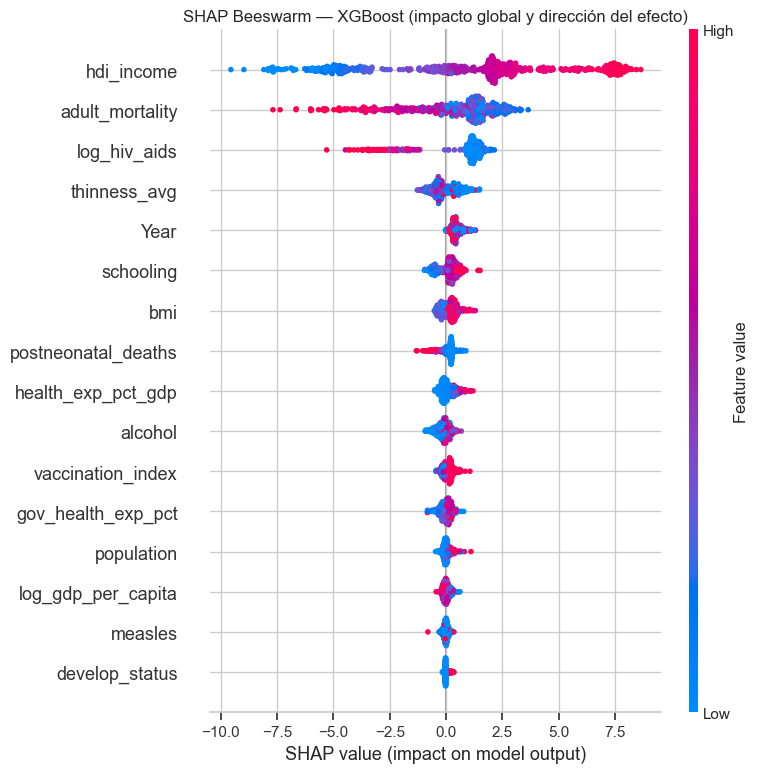

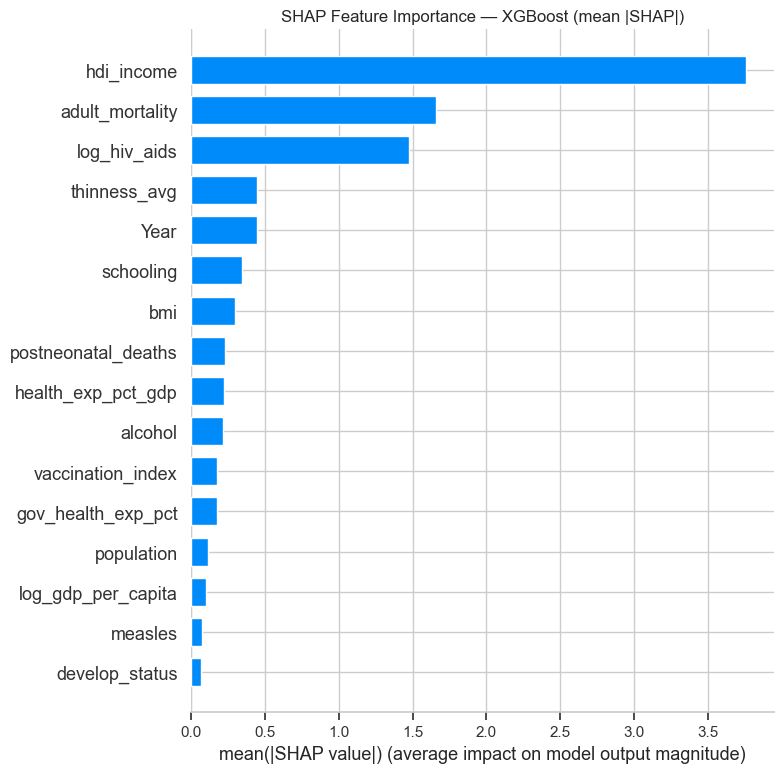

In [43]:
import shap

# Submuestra para acelerar el cálculo
n_shap   = min(1500, X_test.shape[0])
idx_eval = np.random.RandomState(1999).choice(X_test.shape[0], size=n_shap, replace=False)
X_eval   = X_test[idx_eval]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_eval)

# XGBRegressor devuelve array 2-D directamente (no lista)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# --- Beeswarm ---
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_eval, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Beeswarm — XGBoost (impacto global y dirección del efecto)")
plt.tight_layout()
plt.savefig("shap_beeswarm_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Feature Importance (bar) ---
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_eval, feature_names=FEATURE_COLS, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost (mean |SHAP|)")
plt.tight_layout()
plt.savefig("shap_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()